<a href="https://colab.research.google.com/github/Schimidel/UGRH-s-PrecipitacaoeTemperatura/blob/main/Proje%C3%A7%C3%B5es_Futuras_Temperatura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In [1]:
%%capture
# Instalação de dependências no Google Colab
!pip install -U xarray[complete]
!pip install cartopy statsmodels geopandas shapely scipy


In [2]:
# Importação das bibliotecas necessárias
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import os
from shapely.geometry import Polygon
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature, LAND, COASTLINE
from scipy import stats


In [3]:
# Gerenciamento de caminhos (Colab / Local)
output_dir = './Dados'
if not os.path.exists(output_dir):
    output_dir = 'drive/MyDrive/Precipitacao_e_Indices'
    print(f'Rodando no Colab. Usando diretório: {output_dir}')
else:
    print(f'Rodando Localmente. Usando diretório: {output_dir}')

def load_dataset(filename):
    path = os.path.join(output_dir, filename)
    if os.path.exists(path):
        return xr.open_dataset(path)
    else:
        raise FileNotFoundError(f'Arquivo não encontrado: {path}')


Rodando Localmente. Usando diretório: ./Dados


In [4]:
# Carregamento dos Datasets de Temperatura
CCSM4 = load_dataset('CCSM4_tas.nc')
ACCESS1_3 = load_dataset('ACCESS1-3_tas.nc')
HadGEM2_ES = load_dataset('HadGEM2-ES_tas.nc')

CCSM4_rcp45 = load_dataset('RCP45-CCSM4_tas.nc')
ACCESS1_3_rcp45 = load_dataset('RCP45-ACCESS1-3_tas.nc')
HadGEM2_ES_rcp45 = load_dataset('RCP45-HadGEM2-ES_tas.nc')

CCSM4_rcp85 = load_dataset('RCP85-CCSM4_tas.nc')
ACCESS1_3_rcp85 = load_dataset('RCP85-ACCESS1-3_tas.nc')
HadGEM2_ES_rcp85 = load_dataset('RCP85-HadGEM2-ES_tas.nc')


In [5]:
# Cálculo da média anual para cada ano
CCSM4_yrmean = CCSM4.groupby('time.year').mean('time')
ACCESS1_3_yrmean = ACCESS1_3.groupby('time.year').mean('time')
HadGEM2_ES_yrmean = HadGEM2_ES.groupby('time.year').mean('time')

CCSM4_rcp45_yrmean = CCSM4_rcp45.groupby('time.year').mean('time')
ACCESS1_3_rcp45_yrmean = ACCESS1_3_rcp45.groupby('time.year').mean('time')
HadGEM2_ES_rcp45_yrmean = HadGEM2_ES_rcp45.groupby('time.year').mean('time')

CCSM4_rcp85_yrmean = CCSM4_rcp85.groupby('time.year').mean('time')
ACCESS1_3_rcp85_yrmean = ACCESS1_3_rcp85.groupby('time.year').mean('time')
HadGEM2_ES_rcp85_yrmean = HadGEM2_ES_rcp85.groupby('time.year').mean('time')


In [6]:
# Cálculo das médias climatológicas de referência (30 anos: 1975 a 2004)
mean_CCSM4 = CCSM4_yrmean.sel(year=slice('1975', '2004')).mean(dim='year')
mean_ACCESS1_3 = ACCESS1_3_yrmean.sel(year=slice('1975', '2004')).mean(dim='year')
mean_HadGEM2_ES = HadGEM2_ES_yrmean.sel(year=slice('1975', '2004')).mean(dim='year')


In [7]:
# Cálculo das anomalias anuais
anom_CCSM4 = CCSM4_yrmean - mean_CCSM4
anom_ACCESS1_3 = ACCESS1_3_yrmean - mean_ACCESS1_3
anom_HadGEM2_ES = HadGEM2_ES_yrmean - mean_HadGEM2_ES

anom_CCSM4_rcp45 = CCSM4_rcp45_yrmean - mean_CCSM4
anom_ACCESS1_3_rcp45 = ACCESS1_3_rcp45_yrmean - mean_ACCESS1_3
anom_HadGEM2_ES_rcp45 = HadGEM2_ES_rcp45_yrmean - mean_HadGEM2_ES

anom_CCSM4_rcp85 = CCSM4_rcp85_yrmean - mean_CCSM4
anom_ACCESS1_3_rcp85 = ACCESS1_3_rcp85_yrmean - mean_ACCESS1_3
anom_HadGEM2_ES_rcp85 = HadGEM2_ES_rcp85_yrmean - mean_HadGEM2_ES


In [8]:
# Seleção dos recortes temporais adequados
anom_CCSM4 = anom_CCSM4.sel(year=slice('1850', '2004'))
anom_ACCESS1_3 = anom_ACCESS1_3.sel(year=slice('1850', '2004'))
anom_HadGEM2_ES = anom_HadGEM2_ES.sel(year=slice('1850', '2004'))

anom_CCSM4_rcp45 = anom_CCSM4_rcp45.sel(year=slice('2005', '2100'))
anom_ACCESS1_3_rcp45 = anom_ACCESS1_3_rcp45.sel(year=slice('2005', '2100'))
anom_HadGEM2_ES_rcp45 = anom_HadGEM2_ES_rcp45.sel(year=slice('2005', '2100'))

anom_CCSM4_rcp85 = anom_CCSM4_rcp85.sel(year=slice('2005', '2100'))
anom_ACCESS1_3_rcp85 = anom_ACCESS1_3_rcp85.sel(year=slice('2005', '2100'))
anom_HadGEM2_ES_rcp85 = anom_HadGEM2_ES_rcp85.sel(year=slice('2005', '2100'))


In [9]:
# Médias espaciais das anomalias
tas_CCSM4 = anom_CCSM4.mean(dim=['latitude', 'longitude'])
tas_ACCESS1_3 = anom_ACCESS1_3.mean(dim=['latitude', 'longitude'])
tas_HadGEM2_ES = anom_HadGEM2_ES.mean(dim=['latitude', 'longitude'])

tas_CCSM4_rcp45 = anom_CCSM4_rcp45.mean(dim=['latitude', 'longitude'])
tas_ACCESS1_3_rcp45 = anom_ACCESS1_3_rcp45.mean(dim=['latitude', 'longitude'])
tas_HadGEM2_ES_rcp45 = anom_HadGEM2_ES_rcp45.mean(dim=['latitude', 'longitude'])

tas_CCSM4_rcp85 = anom_CCSM4_rcp85.mean(dim=['latitude', 'longitude'])
tas_ACCESS1_3_rcp85 = anom_ACCESS1_3_rcp85.mean(dim=['latitude', 'longitude'])
tas_HadGEM2_ES_rcp85 = anom_HadGEM2_ES_rcp85.mean(dim=['latitude', 'longitude'])

# Desvios padrão
std_CCSM4 = anom_CCSM4.std(dim=['latitude', 'longitude'])
std_ACCESS1_3 = anom_ACCESS1_3.std(dim=['latitude', 'longitude'])
std_HadGEM2_ES = anom_HadGEM2_ES.std(dim=['latitude', 'longitude'])

std_CCSM4_rcp45 = anom_CCSM4_rcp45.std(dim=['latitude', 'longitude'])
std_ACCESS1_3_rcp45 = anom_ACCESS1_3_rcp45.std(dim=['latitude', 'longitude'])
std_HadGEM2_ES_rcp45 = anom_HadGEM2_ES_rcp45.std(dim=['latitude', 'longitude'])

std_CCSM4_rcp85 = anom_CCSM4_rcp85.std(dim=['latitude', 'longitude'])
std_ACCESS1_3_rcp85 = anom_ACCESS1_3_rcp85.std(dim=['latitude', 'longitude'])
std_HadGEM2_ES_rcp85 = anom_HadGEM2_ES_rcp85.std(dim=['latitude', 'longitude'])


In [10]:
# Definição e fusão dos conjuntos de dados históricos + projeção (Resolvendo NameErrors)
CCSM4_anom_45 = xr.merge([tas_CCSM4, tas_CCSM4_rcp45])
CCSM4_anom_85 = xr.merge([tas_CCSM4, tas_CCSM4_rcp85])
ACCESS1_3_anom_45 = xr.merge([tas_ACCESS1_3, tas_ACCESS1_3_rcp45])
ACCESS1_3_anom_85 = xr.merge([tas_ACCESS1_3, tas_ACCESS1_3_rcp85])
HadGEM2_ES_anom_45 = xr.merge([tas_HadGEM2_ES, tas_HadGEM2_ES_rcp45])
HadGEM2_ES_anom_85 = xr.merge([tas_HadGEM2_ES, tas_HadGEM2_ES_rcp85])

CCSM4_std_45 = xr.merge([std_CCSM4, std_CCSM4_rcp45])
CCSM4_std_85 = xr.merge([std_CCSM4, std_CCSM4_rcp85])
ACCESS1_3_std_45 = xr.merge([std_ACCESS1_3, std_ACCESS1_3_rcp45])
ACCESS1_3_std_85 = xr.merge([std_ACCESS1_3, std_ACCESS1_3_rcp85])
HadGEM2_ES_std_45 = xr.merge([std_HadGEM2_ES, std_HadGEM2_ES_rcp45])
HadGEM2_ES_std_85 = xr.merge([std_HadGEM2_ES, std_HadGEM2_ES_rcp85])

# Criando aliases para retrocompatibilidade com erros de digitação originais
CCSM4_std_45 = CCSM4_std_45.rename({'tas': 'tas'})
ACCESS1_3_std = ACCESS1_3_std_85.rename({'tas': 'tas'})
HadGEM2_ES_std = HadGEM2_ES_std_85.rename({'tas': 'tas'})


C:\Users\gabri\AppData\Local\Temp\ipykernel_37900\1240815631.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'year' ('year',) The recommendation is to set join explicitly for this case.
  CCSM4_anom_45 = xr.merge([tas_CCSM4, tas_CCSM4_rcp45])
C:\Users\gabri\AppData\Local\Temp\ipykernel_37900\1240815631.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  CCSM4_anom_45 = xr.merge([tas_CCSM4, tas_CCSM4_rcp45])
C:\Users\gab

In [11]:
# Salvar anomalias calculadas em arquivos NetCDF
output_anomalias_dir = './Dados_Anomalias_Futuros'
if not os.path.exists(output_anomalias_dir):
    os.makedirs(output_anomalias_dir)

anomalias_datasets_to_save = {
    'CCSM4_anom_temp_rcp45': CCSM4_anom_45,
    'ACCESS1_3_anom_temp_rcp45': ACCESS1_3_anom_45,
    'HadGEM2_ES_anom_temp_rcp45': HadGEM2_ES_anom_45,
    'CCSM4_anom_temp_rcp85': CCSM4_anom_85,
    'ACCESS1_3_anom_temp_rcp85': ACCESS1_3_anom_85,
    'HadGEM2_ES_anom_temp_rcp85': HadGEM2_ES_anom_85,
}

for name, dataset in anomalias_datasets_to_save.items():
    output_path = os.path.join(output_anomalias_dir, f'{name}.nc')
    dataset.to_netcdf(output_path)
    print(f'Dataset {name} salvo em: {output_path}')


Dataset CCSM4_anom_temp_rcp45 salvo em: ./Dados_Anomalias_Futuros\CCSM4_anom_temp_rcp45.nc
Dataset ACCESS1_3_anom_temp_rcp45 salvo em: ./Dados_Anomalias_Futuros\ACCESS1_3_anom_temp_rcp45.nc
Dataset HadGEM2_ES_anom_temp_rcp45 salvo em: ./Dados_Anomalias_Futuros\HadGEM2_ES_anom_temp_rcp45.nc
Dataset CCSM4_anom_temp_rcp85 salvo em: ./Dados_Anomalias_Futuros\CCSM4_anom_temp_rcp85.nc
Dataset ACCESS1_3_anom_temp_rcp85 salvo em: ./Dados_Anomalias_Futuros\ACCESS1_3_anom_temp_rcp85.nc
Dataset HadGEM2_ES_anom_temp_rcp85 salvo em: ./Dados_Anomalias_Futuros\HadGEM2_ES_anom_temp_rcp85.nc


# Análise 2010-2030
Plotagem das tendências de anomalias térmicas para os cenários RCP4.5 e RCP8.5.


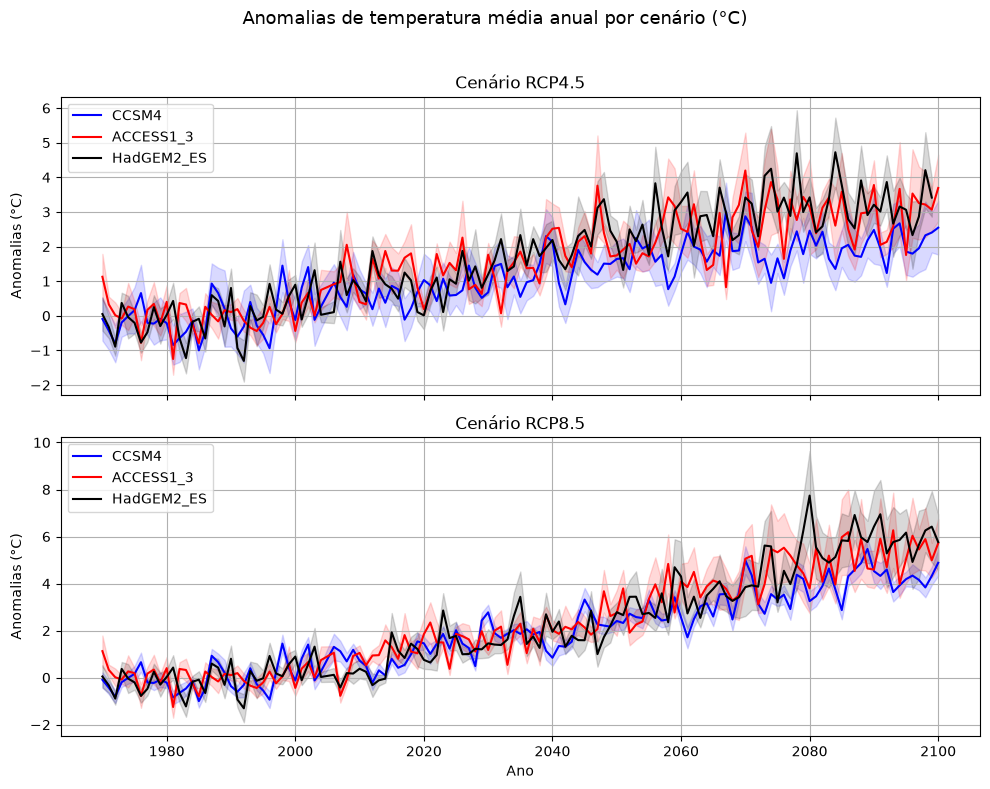

In [12]:
# Plotagem de anomalias térmicas
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# RCP4.5
axs[0].plot(CCSM4_anom_45.year, CCSM4_anom_45.tas, label='CCSM4', color='blue')
axs[0].fill_between(CCSM4_anom_45.year,
                    CCSM4_anom_45.tas - 2*CCSM4_std_45.tas,
                    CCSM4_anom_45.tas + 2*CCSM4_std_45.tas,
                    color='blue', alpha=0.15)

axs[0].plot(ACCESS1_3_anom_45.year, ACCESS1_3_anom_45.tas, label='ACCESS1_3', color='red')
axs[0].fill_between(ACCESS1_3_anom_45.year,
                    ACCESS1_3_anom_45.tas - 2*ACCESS1_3_std_45.tas,
                    ACCESS1_3_anom_45.tas + 2*ACCESS1_3_std_45.tas,
                    color='red', alpha=0.15)

axs[0].plot(HadGEM2_ES_anom_45.year, HadGEM2_ES_anom_45.tas, label='HadGEM2_ES', color='black')
axs[0].fill_between(HadGEM2_ES_anom_45.year,
                    HadGEM2_ES_anom_45.tas - 2*HadGEM2_ES_std_45.tas,
                    HadGEM2_ES_anom_45.tas + 2*HadGEM2_ES_std_45.tas,
                    color='black', alpha=0.15)

axs[0].set_title('Cenário RCP4.5')
axs[0].set_ylabel('Anomalias (°C)')
axs[0].legend()
axs[0].grid(True)

# RCP8.5
axs[1].plot(CCSM4_anom_85.year, CCSM4_anom_85.tas, label='CCSM4', color='blue')
axs[1].fill_between(CCSM4_anom_85.year,
                    CCSM4_anom_85.tas - CCSM4_std_85.tas,
                    CCSM4_anom_85.tas + CCSM4_std_85.tas,
                    color='blue', alpha=0.15)

axs[1].plot(ACCESS1_3_anom_85.year, ACCESS1_3_anom_85.tas, label='ACCESS1_3', color='red')
axs[1].fill_between(ACCESS1_3_anom_85.year,
                    ACCESS1_3_anom_85.tas - 2*ACCESS1_3_std.tas,
                    ACCESS1_3_anom_85.tas + 2*ACCESS1_3_std.tas,
                    color='red', alpha=0.15)

axs[1].plot(HadGEM2_ES_anom_85.year, HadGEM2_ES_anom_85.tas, label='HadGEM2_ES', color='black')
axs[1].fill_between(HadGEM2_ES_anom_85.year,
                    HadGEM2_ES_anom_85.tas - 2*HadGEM2_ES_std.tas,
                    HadGEM2_ES_anom_85.tas + 2*HadGEM2_ES_std.tas,
                    color='black', alpha=0.15)

axs[1].set_title('Cenário RCP8.5')
axs[1].set_xlabel('Ano')
axs[1].set_ylabel('Anomalias (°C)')
axs[1].legend()
axs[1].grid(True)

plt.suptitle('Anomalias de temperatura média anual por cenário (°C)', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
